# Storytelling Data Visualization: Euro Exchange Rates (1999–2021)

### 📊 Introduction
This project analyzes the daily exchange rate between the **Euro (€)** and the **US Dollar ($)** over a 22-year period. Beyond simple data analysis, the goal is to demonstrate **explanatory visualization**—creating graphs that tell a specific story about economic history.

### 🎯 Project Goals
1. **Clean and preprocess** raw exchange rate data for time-series analysis.
2. **Apply smoothing techniques** (Rolling Windows) to highlight long-term trends.
3. **Design explanatory visualizations** using `Matplotlib` and `FiveThirtyEight` style to narrate the Euro's performance during:
    * The 2008 Financial Crisis.
    * Different US Presidential administrations.

### 🛠️ Tech Stack
* **Pandas**: For data manipulation.
* **Matplotlib**: For generating high-quality, storytelling visuals.

## 1. Data Cleaning & Preparation Plan

Before we can tell a story, we must prepare the data. Financial datasets often contain "noise" (weekends, holidays, or missing records) that can break a visualization if not handled correctly.

Our preparation workflow will follow these steps:

1.  **Column Standardization**: Rename columns (e.g., `[US dollar ]` to `US_dollar`) to follow Python naming conventions and make the code cleaner.
2.  **Time-Series Conversion**: Transform the `Time` column from a string (Object) to a `datetime` object to allow for chronological sorting and time-based filtering.
3.  **Data Integrity Check**: The dataset uses a dash (`-`) for days with no recorded rate. We will identify and remove these rows to ensure our currency values are strictly numerical.
4.  **Type Casting**: Convert the exchange rates from strings to `float` for mathematical analysis.
5.  **Signal Smoothing (Rolling Mean)**: Daily exchange rates are highly volatile. To make the trends visible to an audience, we will implement a **30-day Rolling Mean**. This averages out the daily "noise" and highlights the monthly direction of the Euro.

By the end of this stage, we will have a clean, smoothed dataset ready for high-impact storytelling.

In [1]:
import pandas as pd

# Read the dataset
exchange_rates = pd.read_csv('euro-daily-hist_1999_2020.csv')

# Inspect the first five rows
print("First five rows:")
display(exchange_rates.head())

# Inspect the last five rows
print("\nLast five rows:")
display(exchange_rates.tail())

# Basic facts about the dataset
print("\nDataset Info:")
exchange_rates.info()

First five rows:


,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
0,2021-01-08,1.5758,1.9558,6.5748,1.5543,1.0827,7.9184,NaN,26.163,7.4369,...,4.8708,90.8000,10.0510,1.6228,NaN,NaN,36.8480,9.0146,1.2250,18.7212
1,2021-01-07,1.5836,1.9558,6.5172,1.5601,1.0833,7.9392,NaN,26.147,7.4392,...,4.8712,91.2000,10.0575,1.6253,NaN,NaN,36.8590,8.9987,1.2276,18.7919
2,2021-01-06,1.5824,1.9558,6.5119,1.5640,1.0821,7.9653,NaN,26.145,7.4393,...,4.8720,90.8175,10.0653,1.6246,NaN,NaN,36.9210,9.0554,1.2338,18.5123
3,2021-01-05,1.5927,1.9558,6.5517,1.5651,1.0803,7.9315,NaN,26.227,7.4387,...,4.8721,91.6715,10.0570,1.6180,NaN,NaN,36.7760,9.0694,1.2271,18.4194
4,2021-01-04,1.5928,1.9558,6.3241,1.5621,1.0811,7.9484,NaN,26.141,7.4379,...,4.8713,90.3420,10.0895,1.6198,NaN,NaN,36.7280,9.0579,1.2296,17.9214



Last five rows:


,Period\Unit:,[Australian dollar ],[Bulgarian lev ],[Brazilian real ],[Canadian dollar ],[Swiss franc ],[Chinese yuan renminbi ],[Cypriot pound ],[Czech koruna ],[Danish krone ],...,[Romanian leu ],[Russian rouble ],[Swedish krona ],[Singapore dollar ],[Slovenian tolar ],[Slovak koruna ],[Thai baht ],[Turkish lira ],[US dollar ],[South African rand ]
5694,1999-01-08,1.8406,NaN,NaN,1.7643,1.6138,NaN,0.58187,34.938,7.4433,...,1.3143,27.2075,9.1650,1.9537,188.8400,42.560,42.5590,0.3718,1.1659,6.7855
5695,1999-01-07,1.8474,NaN,NaN,1.7602,1.6165,NaN,0.58187,34.886,7.4431,...,1.3092,26.9876,9.1800,1.9436,188.8000,42.765,42.1678,0.3701,1.1632,6.8283
5696,1999-01-06,1.8820,NaN,NaN,1.7711,1.6116,NaN,0.58200,34.850,7.4452,...,1.3168,27.4315,9.3050,1.9699,188.7000,42.778,42.6949,0.3722,1.1743,6.7307
5697,1999-01-05,1.8944,NaN,NaN,1.7965,1.6123,NaN,0.58230,34.917,7.4495,...,1.3168,26.5876,9.4025,1.9655,188.7750,42.848,42.5048,0.3728,1.1790,6.7975
5698,1999-01-04,1.9100,NaN,NaN,1.8004,1.6168,NaN,0.58231,35.107,7.4501,...,1.3111,25.2875,9.4696,1.9554,189.0450,42.991,42.6799,0.3723,1.1789,6.9358



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5699 entries, 0 to 5698
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Period\Unit:              5699 non-null   object 
 1   [Australian dollar ]      5699 non-null   object 
 2   [Bulgarian lev ]          5297 non-null   object 
 3   [Brazilian real ]         5431 non-null   object 
 4   [Canadian dollar ]        5699 non-null   object 
 5   [Swiss franc ]            5699 non-null   object 
 6   [Chinese yuan renminbi ]  5431 non-null   object 
 7   [Cypriot pound ]          2346 non-null   object 
 8   [Czech koruna ]           5699 non-null   object 
 9   [Danish krone ]           5699 non-null   object 
 10  [Estonian kroon ]         3130 non-null   object 
 11  [UK pound sterling ]      5699 non-null   object 
 12  [Greek drachma ]          520 non-null    object 
 13  [Hong Kong dollar ]       5699 non-null   object

### 🔍 Initial Data Observations

After inspecting the data, several key facts emerge that will guide our cleaning and analysis phase:

* **Dimensions**: The dataset consists of **5,699 rows** and **41 columns**.
* **Missing Values**:
    * While some columns appear complete, a call to `.info()` reveals that several currencies have null values (e.g., `Greek drachma`, `Slovenian tolar`), likely due to these nations joining the Eurozone at different times.
    * Many columns are stored as the `object` (string) data type rather than `float`. This is a significant red flag, suggesting that missing data might be represented by non-numeric characters (like hyphens or dashes) instead of standard NaN values.
* **Data Types**:
    * The `Period\Unit:` column (our date source) is currently an object. To perform time-series analysis, we will need to convert this to a `datetime` format.
    * The currency columns must be cast to `float` to allow for mathematical operations and visualization.

**Next Step**: We will proceed to data cleaning to standardize the columns and prepare the Euro-to-Dollar exchange rate for visualization.

## 2. Data Cleaning

To focus our analysis on the Euro-USD relationship, we need to perform several cleaning steps. Financial data often contains non-trading days or formatting inconsistencies that must be resolved before any visualization can take place.

**Our cleaning workflow includes:**
1. **Renaming Columns**: Simplifying headers for better code readability.
2. **Type Conversion**: Ensuring dates are recognized as `datetime` objects and currency values as `floats`.
3. **Data Filtering**: Identifying and removing rows with missing values (represented as `-`).

In [2]:
# Rename columns for clarity
exchange_rates.rename(columns={'[US dollar ]': 'US_dollar',
                               'Period\\Unit:': 'Time'},
                      inplace=True)

# Convert Time to datetime and sort chronologically
exchange_rates['Time'] = pd.to_datetime(exchange_rates['Time'])
exchange_rates.sort_values('Time', inplace=True)
exchange_rates.reset_index(drop=True, inplace=True)

# Isolate the Time and US_dollar columns
euro_to_dollar = exchange_rates[['Time', 'US_dollar']].copy()

# Inspecting the US_dollar column for anomalies
print("Value counts for US_dollar (top 5):")
print(euro_to_dollar['US_dollar'].value_counts().head())

Value counts for US_dollar (top 5):
US_dollar
-         62
1.2276     9
1.1215     8
1.1305     7
1.1797     6
Name: count, dtype: int64


### Identification of "Hyphen" Data
Upon running `value_counts()`, we notice that the character **'-'** appears **62 times** in the `US_dollar` column. These entries represent days where no exchange rate was recorded (e.g., bank holidays). Because a hyphen is a string, it prevents the entire column from being treated as a numeric type. We must remove these rows to perform any mathematical smoothing or plotting.

In [3]:
# Drop rows where '-' appears
euro_to_dollar = euro_to_dollar[euro_to_dollar['US_dollar'] != '-']

# Convert the US_dollar column to float
euro_to_dollar['US_dollar'] = euro_to_dollar['US_dollar'].astype(float)

# Final check of the data types and null values
print("Cleaned euro_to_dollar information:")
euro_to_dollar.info()

Cleaned euro_to_dollar information:
<class 'pandas.core.frame.DataFrame'>
Index: 5637 entries, 0 to 5698
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Time       5637 non-null   datetime64[ns]
 1   US_dollar  5637 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 132.1 KB


## 3. Making the Graph Easier to Read (Rolling Mean)

If we plot the daily exchange rates, the graph looks very messy. It jumps up and down every single day. This daily jumping is just "noise" that makes it hard to see the big picture.

To fix this, we will use a **Rolling Mean** (also called a Moving Average) with a 30-day window. This means that for every day, the graph will show the average rate of the last 30 days. This smooths out the line and helps us see the real long-term trends.

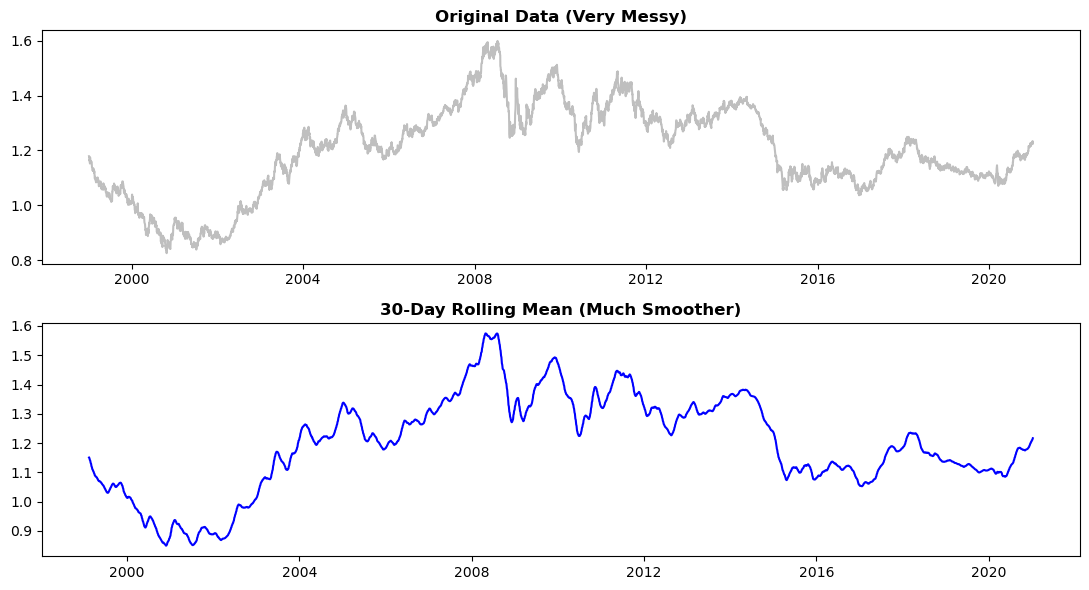

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

# Calculate the 30-day rolling mean
euro_to_dollar['rolling_mean'] = euro_to_dollar['US_dollar'].rolling(30).mean()

# Let's plot the original data next to the smoothed data to see the difference
plt.figure(figsize=(11, 6))

# Graph 1: Noisy data
plt.subplot(2, 1, 1)
plt.plot(euro_to_dollar['Time'], euro_to_dollar['US_dollar'], color='gray', alpha=0.5)
plt.title('Original Data (Very Messy)', weight='bold')

# Graph 2: Clean data (30-day average)
plt.subplot(2, 1, 2)
plt.plot(euro_to_dollar['Time'], euro_to_dollar['rolling_mean'], color='blue')
plt.title('30-Day Rolling Mean (Much Smoother)', weight='bold')

plt.tight_layout()
plt.show()

### What the Graphs Show us

* **The Top Graph**: It has too many lines and spikes. It is hard to see when the Euro was actually doing well or bad.
* **The Bottom Graph**: The blue line is much cleaner. The daily jumps are gone, but we can still clearly see the big historical drops and rises.

We will use this clean 30-day average to tell our economic stories in the next steps.

## 4. Our Visual Story: The Three US Presidents Era

To create an interesting story for employers, we will compare how the Euro-to-USD exchange rate changed under three different US Presidential administrations:

1. **George W. Bush** (2001–2009)
2. **Barack Obama** (2009–2017)
3. **Donald Trump** (2017–2021)

### Why this is an interesting story:
* **Historical Events**: This 20-year period includes major global events like the 2008 Financial Crisis, the European Debt Crisis, and the start of the COVID-19 pandemic.
* **Visual Challenge**: Instead of showing one giant line, we will build a beautiful layout with three separate small charts (one for each president) and one large summary chart at the bottom. This is exactly what professional data journalists do at places like FiveThirtyEight.

### 🎨 Wireframe & Design Blueprint

Before writing the Matplotlib code, we will sketch out the structure of our visual narrative. We want a clean, professional grid that follows the **FiveThirtyEight** layout design.

#### 📐 The Grid Layout
We will create a multi-panel chart with **4 subplots** in total:
* **Top Row**: Three individual small charts side-by-side.
    * **Chart 1**: George W. Bush era (2001–2009)
    * **Chart 2**: Barack Obama era (2009–2017)
    * **Chart 3**: Donald Trump era (2017–2021)
* **Bottom Row**: One single, large combined chart showing the entire 2001–2021 timeline. This helps the viewer see how the eras connect.

#### 🎨 Visual Language & Design Choices
* **Data-Ink Ratio**: We will remove all unnecessary elements. No top or right borders (spines), minimal gridlines, and no default X/Y axis titles that cause clutter.
* **Pre-attentive Attributes (Colors)**: Each president will get a unique, distinct color to make identification instant:
    * **George W. Bush**: Purple (`#BF5FFF`)
    * **Barack Obama**: Orange (`#ffa500`)
    * **Donald Trump**: Blue (`#00B2EE`)
* **Typography**: The title will be bold and prominent at the top left, with a smaller descriptive subtitle directly underneath to explain the core insight immediately.
* **Signature**: A professional footer at the bottom containing the author name and the data source.